<a href="https://colab.research.google.com/github/Renad110/IT326/blob/main/Reports/Phase3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Project Goal
The goal of this project is to perform classification and clustering tasks on the Bank Marketing dataset.

- Classification: Predict whether a client will subscribe to a term deposit.
- Clustering: Group clients with similar characteristics.

## Dataset Source
The dataset used in this project is the Bank Marketing Dataset, obtained from the UCI Machine Learning Repository.

- Source: UCI Machine Learning Repository – Bank Marketing Dataset  
- Link: [https://archive.ics.uci.edu/dataset/222/bank+marketing](https://archive.ics.uci.edu/dataset/222/bank+marketing)  
- DOI: [https://doi.org/10.1016/j.dss.2014.03.001](https://doi.org/10.1016/j.dss.2014.03.001)

Dataset

Source: UCI Machine Learning Repository - Bank Marketing Dataset
File Used: bank-additional-full.csv
Rows: 41,188
Columns (features): 20
Class Label: y (yes/no) — whether the client subscribed to a bank term deposit.

In [60]:
import pandas as pd

data = pd.read_csv('bank-additional-full.csv', sep=';')

print("Number of instances (rows):", data.shape[0])
print("Number of attributes (columns):", data.shape[1])
print("\nClass Attribute (y) value counts:\n", data['y'].value_counts())
print("\nSample of the dataset:\n", data.head())

Number of instances (rows): 41188
Number of attributes (columns): 21

Class Attribute (y) value counts:
 y
no     36548
yes     4640
Name: count, dtype: int64

Sample of the dataset:
    age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1 

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler
df = pd.read_csv('bank-additional-full.csv', sep=';')
raw_df = df.copy()


🔹 Statistical & Data Overview Analysis:
In this section, we explore the dataset by showing its structure, statistical summary, missing values, and outliers. This helps us understand data quality and what preprocessing might be needed later.

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

The dataset contains 41188 rows and 21 columns.  
Most of the attributes are either categorical or numeric,  
which means both types of analysis will be needed.

In [63]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


The table above provides a five-number summary and basic statistics for the numerical columns.
For example, we can see that the average of most numerical attributes, such as `age` and `duration`,
shows moderate variation between the minimum and maximum values, which helps identify data spread and potential outliers.


In [64]:
missing_values = df.isna().sum()
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


Missing Values Analysis:
We checked for missing values in each column. The output shows that all columns have zero missing values,
which means the dataset is complete and no imputation is required at this stage.


In [65]:
from scipy.stats import zscore
# sample dataset
data = df['age']

z_scores = zscore(data)
threshold = 2

outliers = data[abs(z_scores) > threshold]
print("Outliers:", outliers)


Outliers: 8645     61
15798    19
24110    18
27713    70
27715    61
         ..
41174    62
41178    62
41179    64
41183    73
41187    74
Name: age, Length: 985, dtype: int64


Outliers Detection: We used the Z-Score method on the age column to detect unusual values.
This method can also be applied to other numeric columns to find outliers.
The detected extreme values will be handled later during preprocessing.

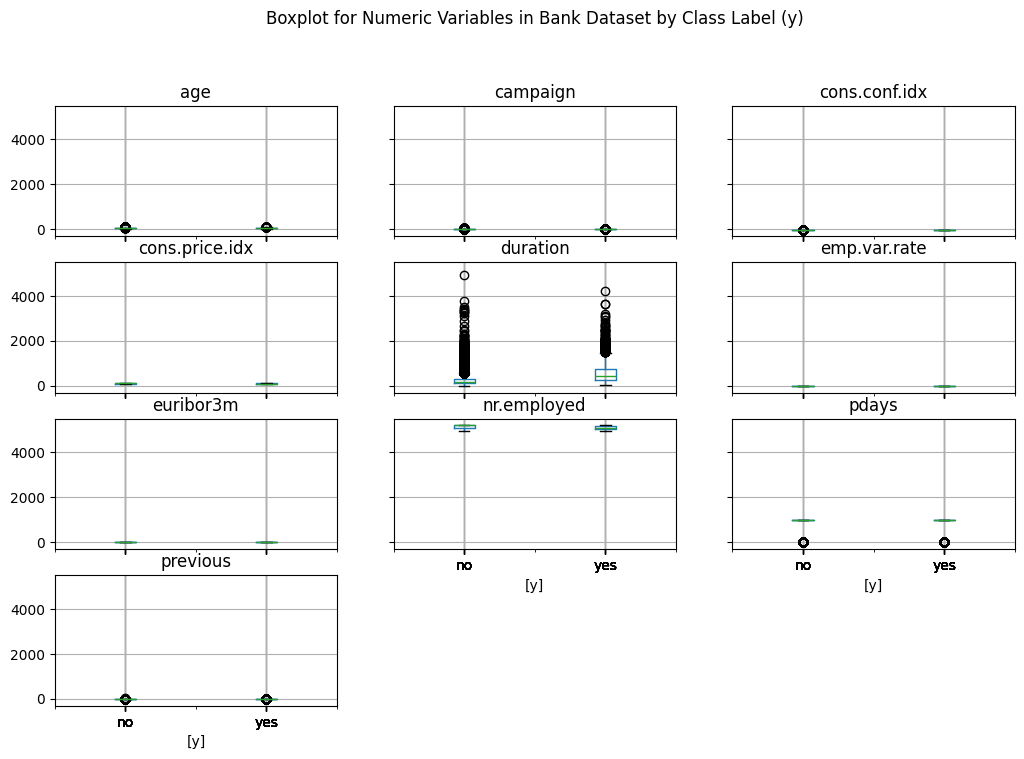

In [66]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('bank-additional-full.csv', sep=';')
df.boxplot(by='y', figsize=(12, 8))
plt.suptitle('Boxplot for Numeric Variables in Bank Dataset by Class Label (y)', y=1.02)
plt.show()

The boxplot shows the distribution of numeric variables in the dataset, grouped by the target variable (y).
It helps identify outliers and compare how values differ between the “yes” and “no” classes.
For example, the “duration” variable shows more spread and outliers, which indicates it may strongly influence the model during training.

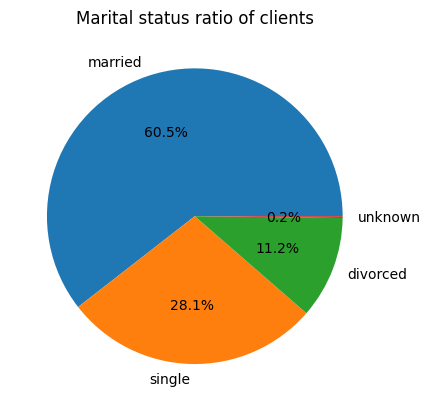

In [67]:
import matplotlib.pyplot as plt
df["marital"].value_counts().plot(kind="pie", autopct="%.1f%%", title="Marital status ratio of clients")
plt.ylabel("")
plt.show()

The pie chart shows that most clients are married, followed by single and divorced groups. It reveals a class imbalance leaning toward a specific social category. During preprocessing, this helps handle class bias or merge minor groups to maintain balanced data before encoding.

 This insight can later support feature selection by testing whether marital status significantly influences the subscription outcome.

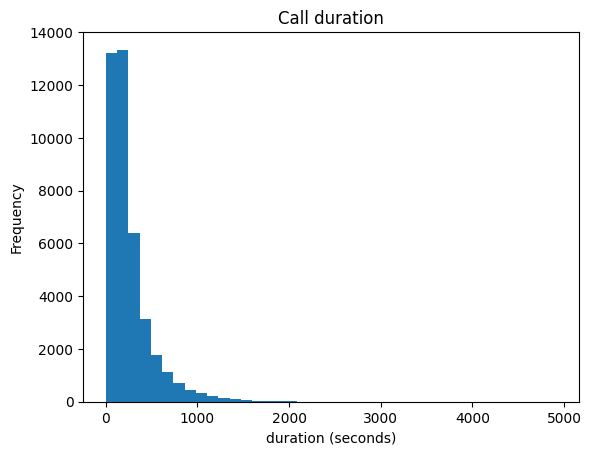

In [68]:
df["duration"].plot(kind="hist", bins=40, title="Call duration")
plt.xlabel("duration (seconds)")
plt.ylabel("Frequency")
plt.show()

The histogram shows the distribution of call durations, where most calls are short and few are long. It highlights large variation and potential outliers, which helps in preprocessing by applying normalization or removing extreme values to improve data quality.

It can later help determine whether call duration is a key predictive feature affecting client responses to campaigns.

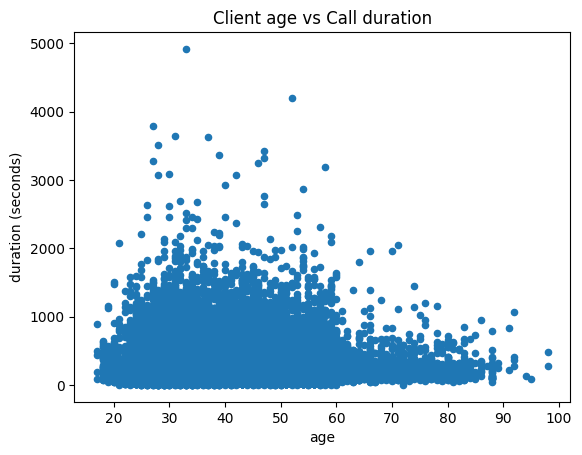

In [69]:
df.plot.scatter(x="age", y="duration", title="Client age vs Call duration")
plt.xlabel("age")
plt.ylabel("duration (seconds)")
plt.show()

The scatter plot shows the relationship between client age and call duration. It suggests that age has little effect on call length, which helps in preprocessing by analyzing feature correlation and deciding on normalization or feature selection.

This relationship can help evaluate whether age is a meaningful factor for understanding customer behavior or can be excluded.

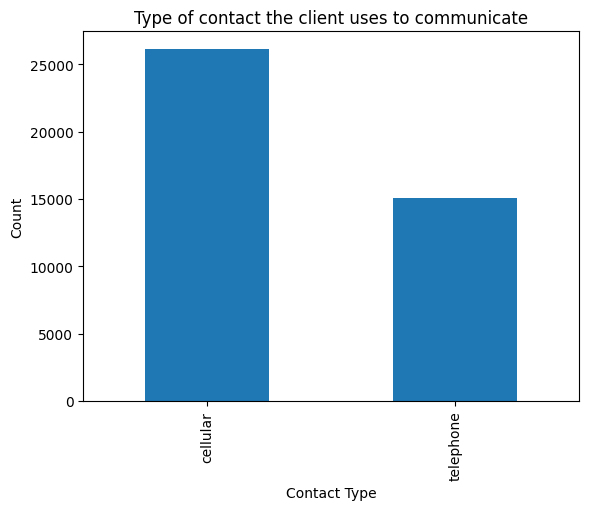

In [70]:
df['contact'].value_counts().plot(kind='bar', title='Type of contact the client uses to communicate')
plt.xlabel('Contact Type')
plt.ylabel('Count')
plt.show()

The bar chart shows that most clients were contacted via cellular phones rather than landlines, indicating the bank’s reliance on modern communication channels. This insight helps in preprocessing by applying categorical encoding and ensuring class balance.

this feature can be analyzed to see whether the contact method significantly affects client response or not.

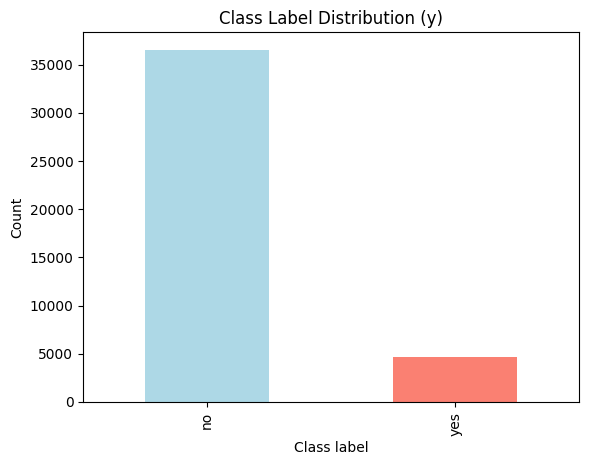

In [71]:
import matplotlib.pyplot as plt
df['y'].value_counts().plot(kind='bar', color=['lightblue', 'salmon'])
plt.title('Class Label Distribution (y)')
plt.xlabel('Class label')
plt.ylabel('Count')
plt.show()

Class Label Distribution: The bar plot shows the number of samples for each class in the target variable (y).
The dataset is imbalanced, with significantly more “no” responses than “yes.”
This imbalance should be considered during preprocessing or model training to ensure fair prediction performance.



---


**Data Preprocessing**
-

In [72]:

Q1 = df['duration'].quantile(0.25)
Q3 = df['duration'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

initial_len = len(df)
df = df[(df['duration'] <= upper_bound)].copy()

df['log_duration'] = np.log1p(df['duration'])

print(f"Cleaned 'duration' column. Initial rows: {initial_len}, Remaining rows: {len(df)}")



bins = [17, 30, 45, 60, 100]
labels = ['Youth (18-29)', 'Adult (30-44)', 'Middle Age (45-59)', 'Senior (60+)']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

print("Successfully created 'age_group' column through Discretization.")


scaler = MinMaxScaler()
numeric_cols = ['age', 'duration', 'campaign', 'pdays', 'previous',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
    'euribor3m', 'nr.employed', 'log_duration']
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("Numeric columns normalized successfully.")

print("- Before Preprocessing:")
display(raw_df.head())

print("- After Preprocessing:")
display(df.head())


Cleaned 'duration' column. Initial rows: 41188, Remaining rows: 38225
Successfully created 'age_group' column through Discretization.
Numeric columns normalized successfully.
- Before Preprocessing:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


- After Preprocessing:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,log_duration,age_group
0,0.481481,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,0.0,nonexistent,0.9375,0.698753,0.60251,0.957379,0.859735,no,0.860740,Middle Age (45-59)
1,0.493827,services,married,high.school,unknown,no,no,telephone,may,mon,...,0.0,nonexistent,0.9375,0.698753,0.60251,0.957379,0.859735,no,0.774531,Middle Age (45-59)
2,0.246914,services,married,high.school,no,yes,no,telephone,may,mon,...,0.0,nonexistent,0.9375,0.698753,0.60251,0.957379,0.859735,no,0.838575,Adult (30-44)
3,0.283951,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,0.0,nonexistent,0.9375,0.698753,0.60251,0.957379,0.859735,no,0.776578,Adult (30-44)
4,0.481481,services,married,high.school,no,no,yes,telephone,may,mon,...,0.0,nonexistent,0.9375,0.698753,0.60251,0.957379,0.859735,no,0.885744,Middle Age (45-59)


**Data Preprocessing Justification**

In this phase, several preprocessing techniques were applied to improve the dataset’s quality and prepare it for the data mining phase. The applied techniques include Noise Removal, Variable Transformation, Discretization, and Normalization.

**Noise Removal (Outlier Handling)**

* **Why:** Outliers in the duration column can negatively affect the analysis and model performance since they distort the scale of the data and bias statistical measures.

* **How:** The Interquartile Range (IQR) method was used to identify and remove extreme values above the upper bound (Q3 + 1.5*IQR).

* **On which attribute:** duration

* **Improvement:** Removing outliers reduced data variability and made the distribution more consistent, which helps classification and clustering algorithms perform more accurately.


**Variable Transformation (Log Transformation)**

* **Why:** The duration attribute had a highly skewed distribution. Log transformation was used to reduce skewness and make the data more normally distributed.

* **How:** A new column log_duration was created using the transformation log1p(duration).

* **On which attribute:** duration

* **Improvement:** The transformation reduced the impact of large values, allowing algorithms like Decision Trees and K-Means to treat all samples more equally.

**Discretization (Binning)**

* **Why:** Continuous numerical data in the age attribute was converted into categorical age groups to simplify interpretation and improve model interpretability.

* **How:** The age column was divided into four bins.

* **On which attribute:** age

* **Improvement:** This technique made the data more understandable and suitable for classification algorithms that can benefit from categorical features.

**Normalization (Min–Max Scaling)**

* **Why:** The numeric attributes had different scales (e.g., age, duration, etc.), which can bias distance-based algorithms such as K-Means.

* **How:** The Min–Max Scaler from sklearn was applied to rescale all numeric features into the range [0, 1].

* **On which attributes:** Numeric attributes.

* **Improvement:** Scaling unified the range of values across features, ensuring that all attributes contribute equally to the learning process.

**Summary of Results**

After preprocessing, the dataset became cleaner, more balanced, and more suitable for machine learning tasks. Outliers were removed, distributions were smoothed, and numeric attributes were scaled consistently.

In [73]:
# Save the preprocessed dataset
df.to_csv('Preprocessed_dataset.csv', index=False)


---

**Classification**
-

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

In [75]:
data = pd.read_csv('Preprocessed_dataset.csv')
df_encoded = data.copy()
le = LabelEncoder()

for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

In [76]:
test_sizes = [0.2, 0.3, 0.4]
criteria = ["gini", "entropy"]

results_list = []

print("=" * 75)
print(f"{'Test Split %':<15} | {'Criterion':<10} | {'Accuracy':<10} | {'F1-Score (Yes)':<15}")
print("=" * 75)

Test Split %    | Criterion  | Accuracy   | F1-Score (Yes) 


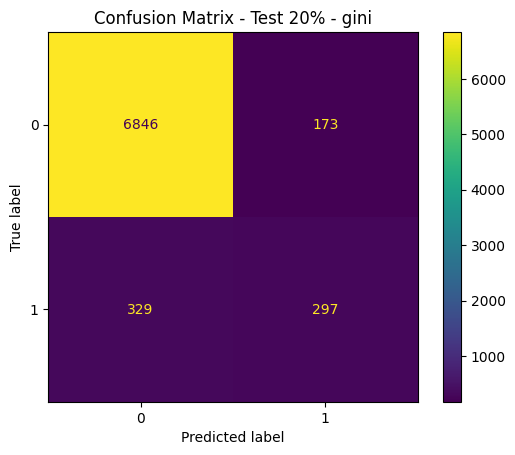

20              | gini       | 0.9343


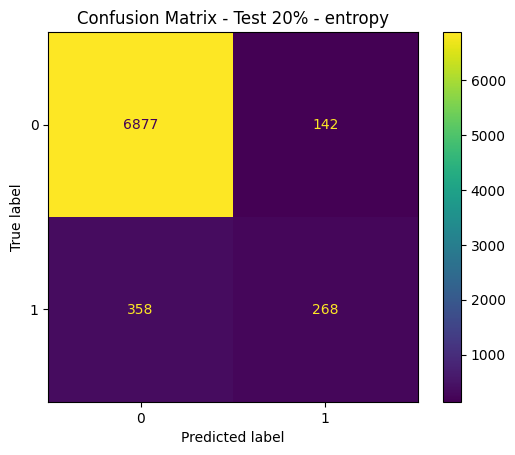

20              | entropy    | 0.9346


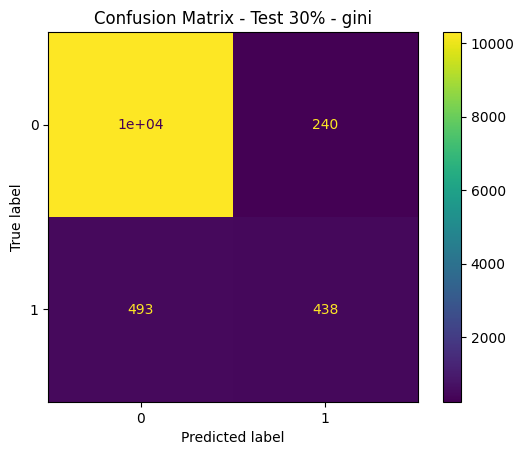

30              | gini       | 0.9361


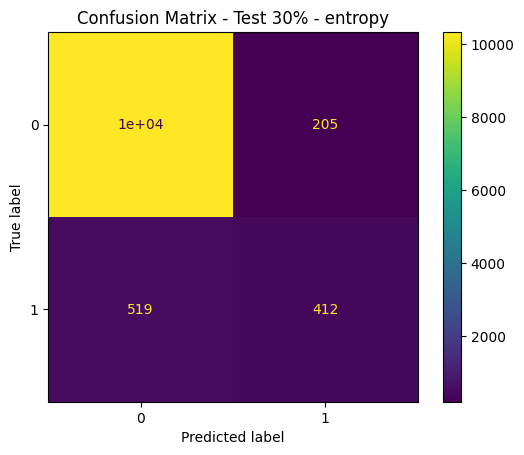

30              | entropy    | 0.9369


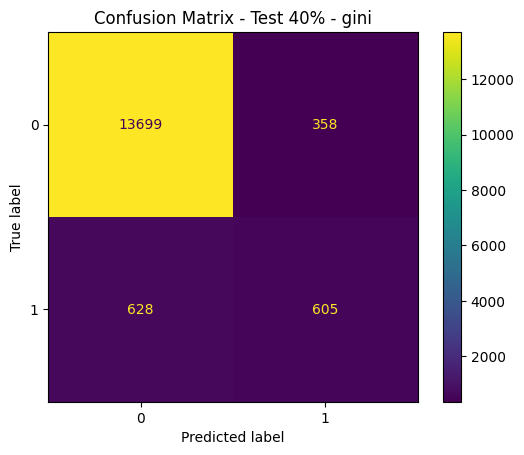

40              | gini       | 0.9355


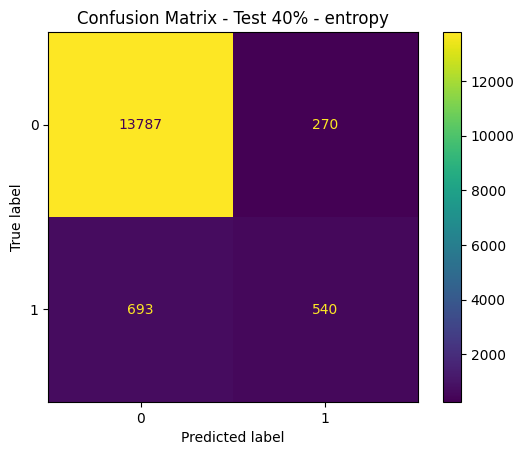

40              | entropy    | 0.9370


In [77]:
for t_size in test_sizes:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=t_size, random_state=42)

    for crit in criteria:
        clf = DecisionTreeClassifier(criterion=crit, max_depth=4, random_state=42)

        clf.fit(X_train, y_train)

        y_pred = clf.predict(X_test)

        acc = accuracy_score(y_test, y_pred)

        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot()
        plt.title(f"Confusion Matrix - Test {int(t_size*100)}% - {crit}")
        plt.show()

        results_list.append({
            "Test Size": f"{t_size*100}%",
            "Criterion": crit,
            "Accuracy": acc,
            "Model": clf
        })

        print(f"{t_size*100:<15.0f} | {crit:<10} | {acc:.4f}")

print("=" * 75)

Generating 6 Decision Tree visualizations as separate outputs...


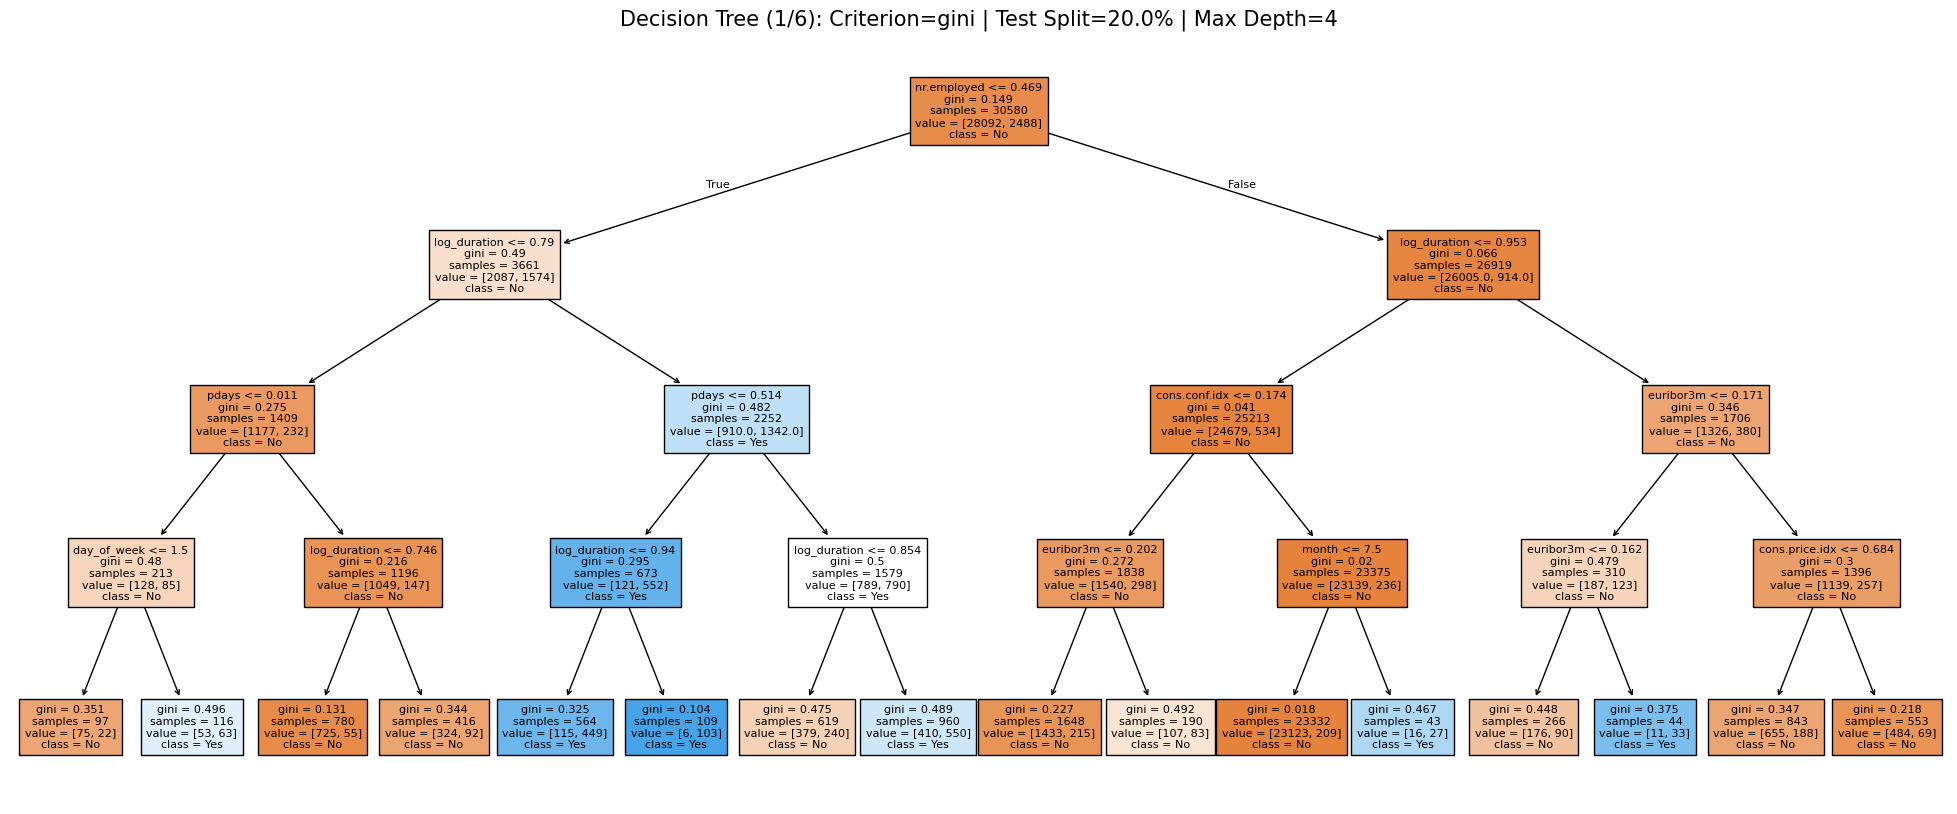

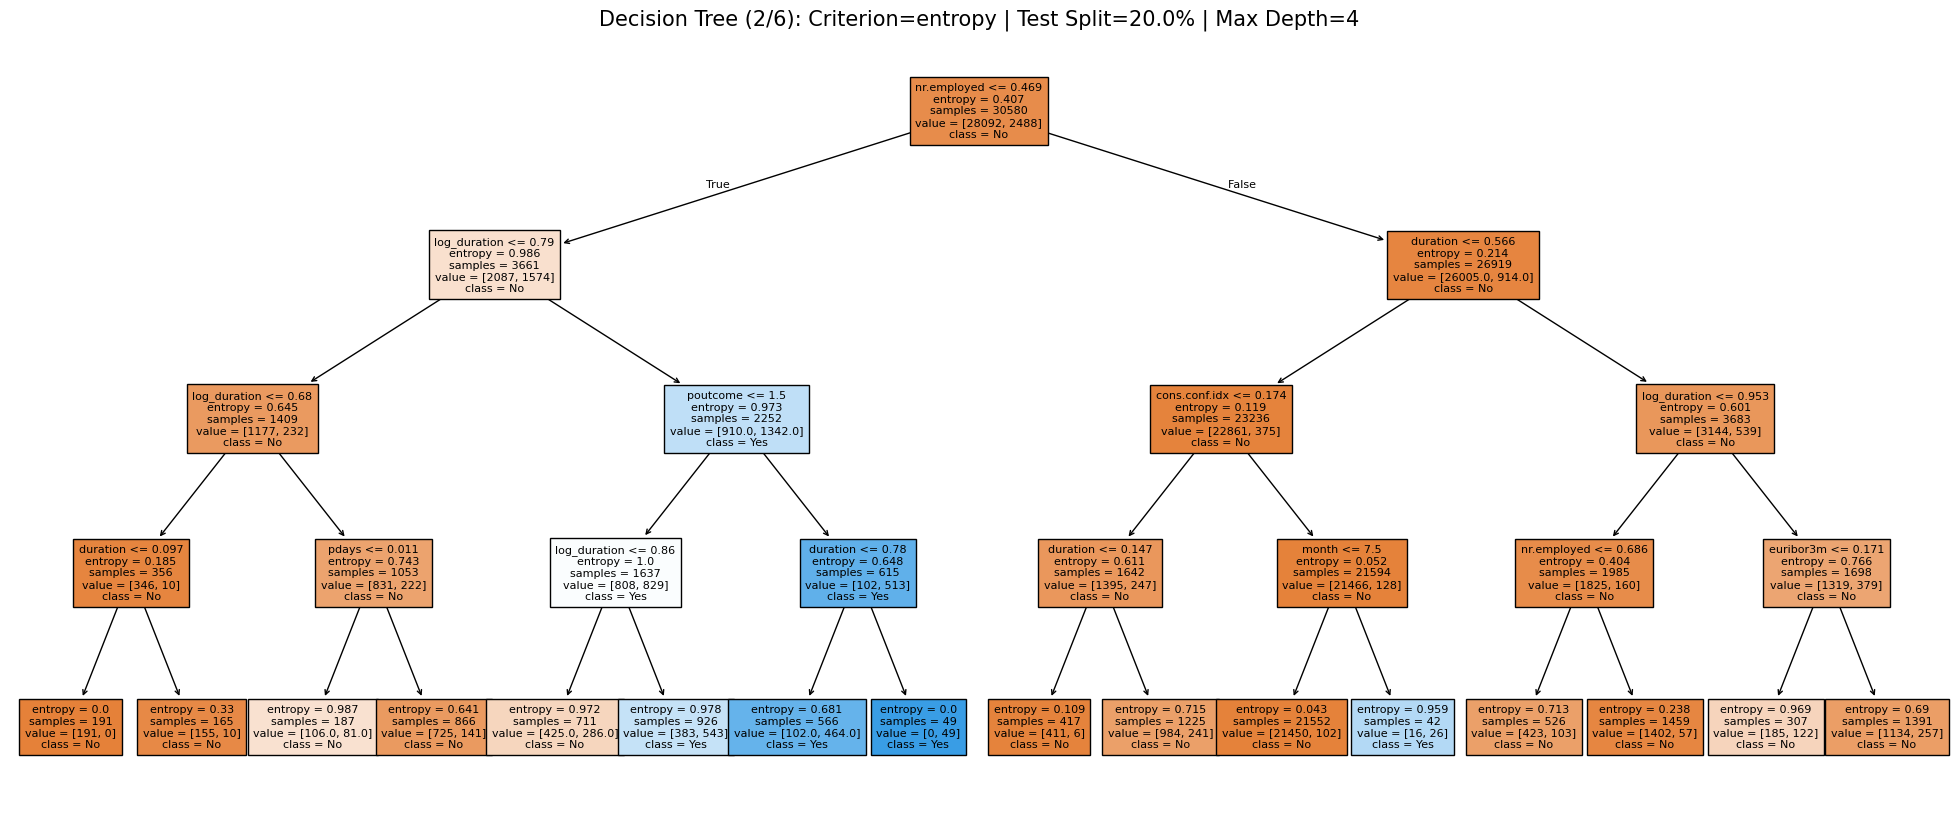

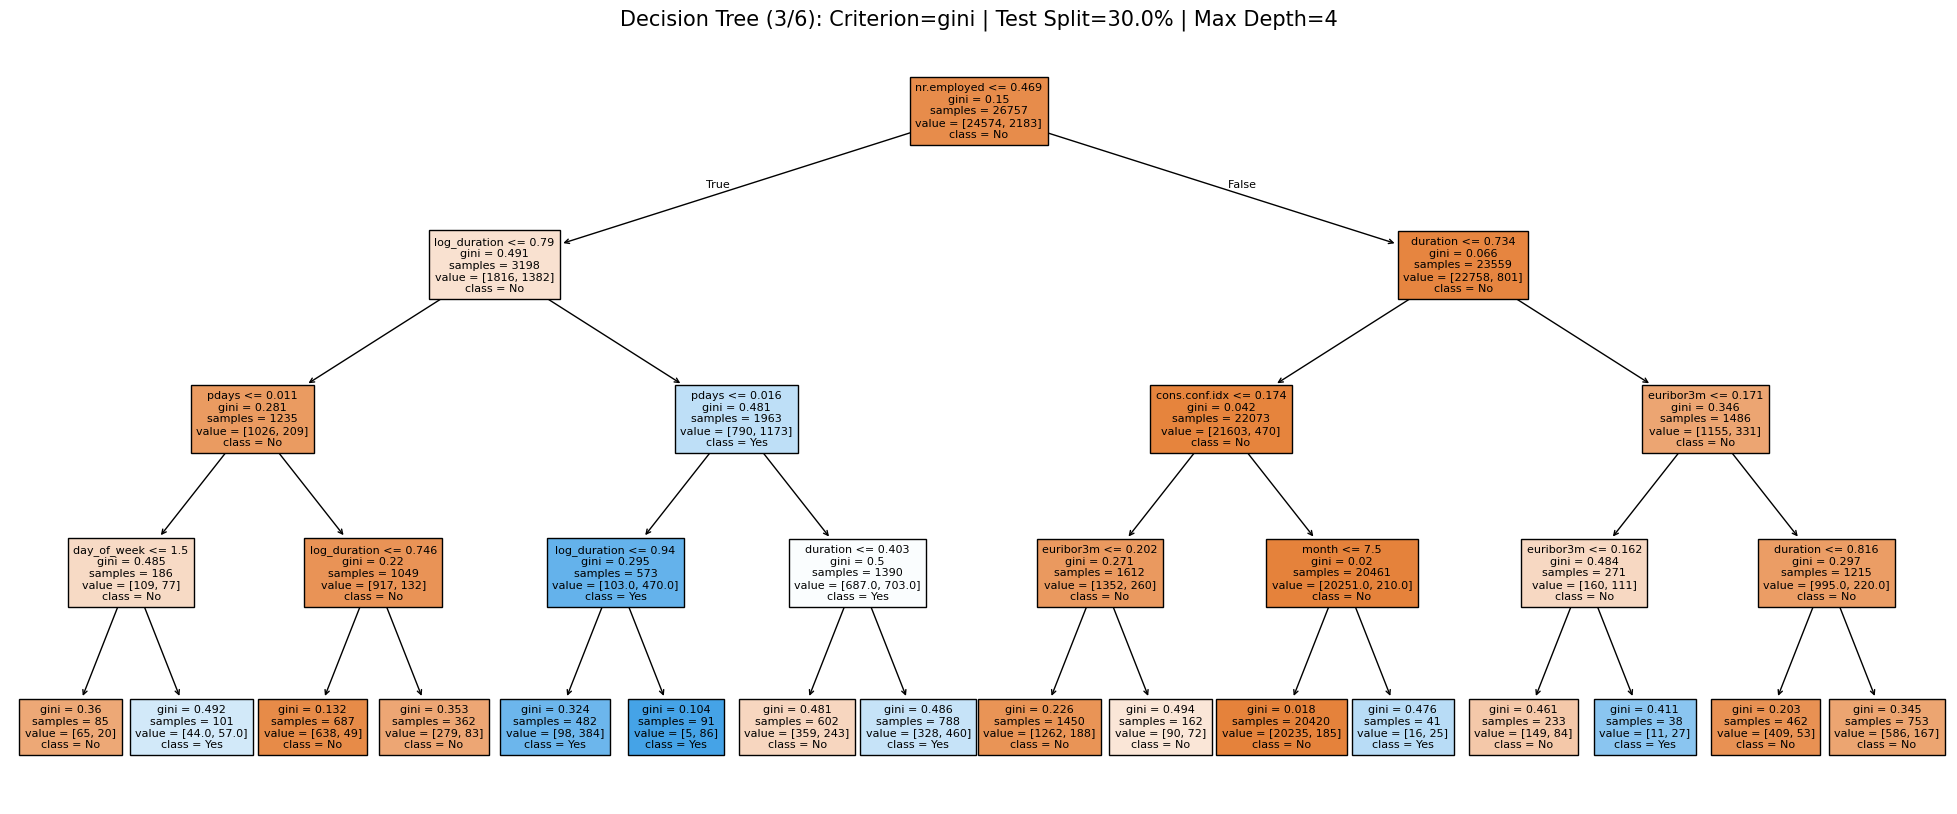

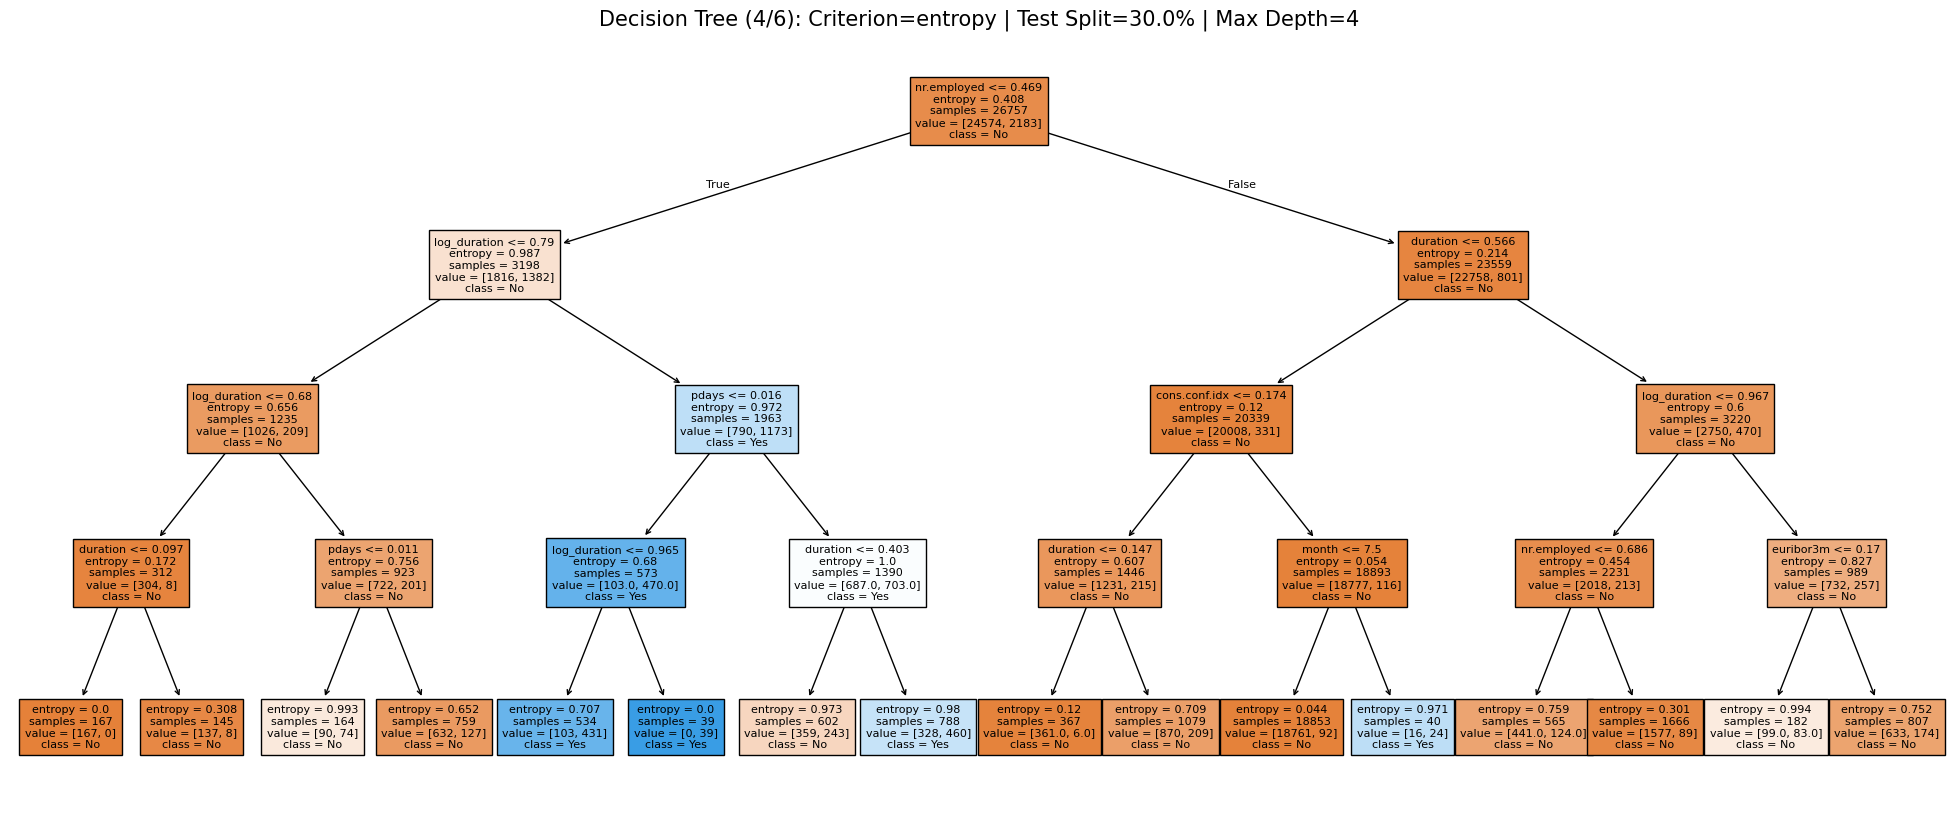

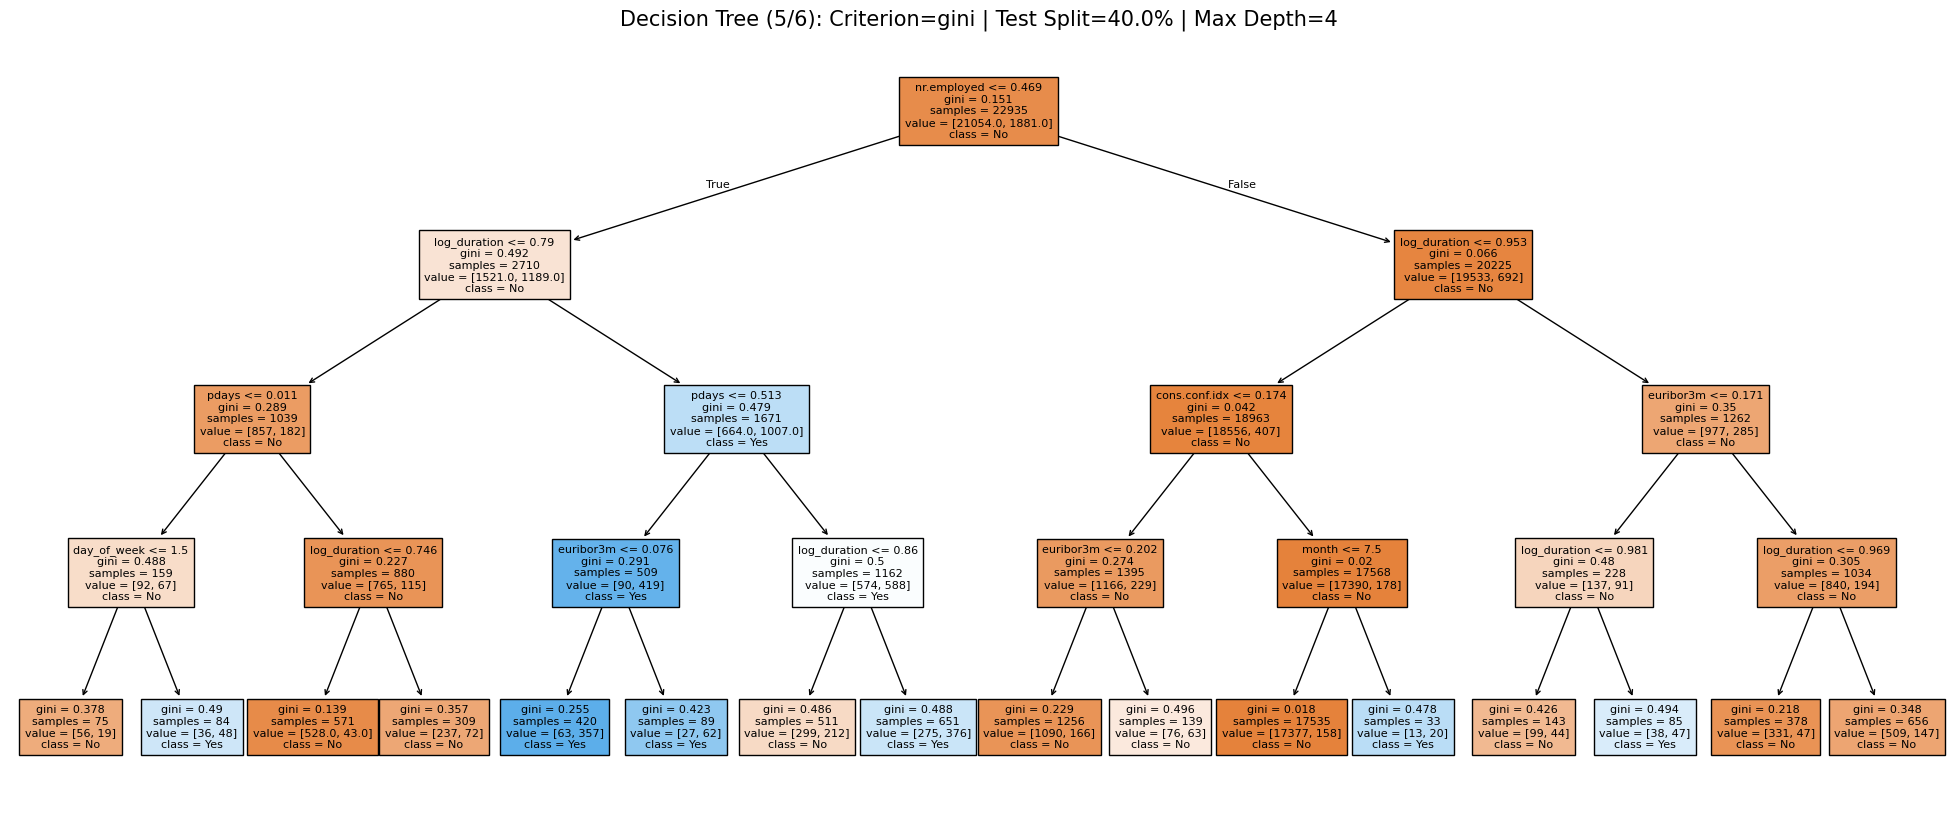

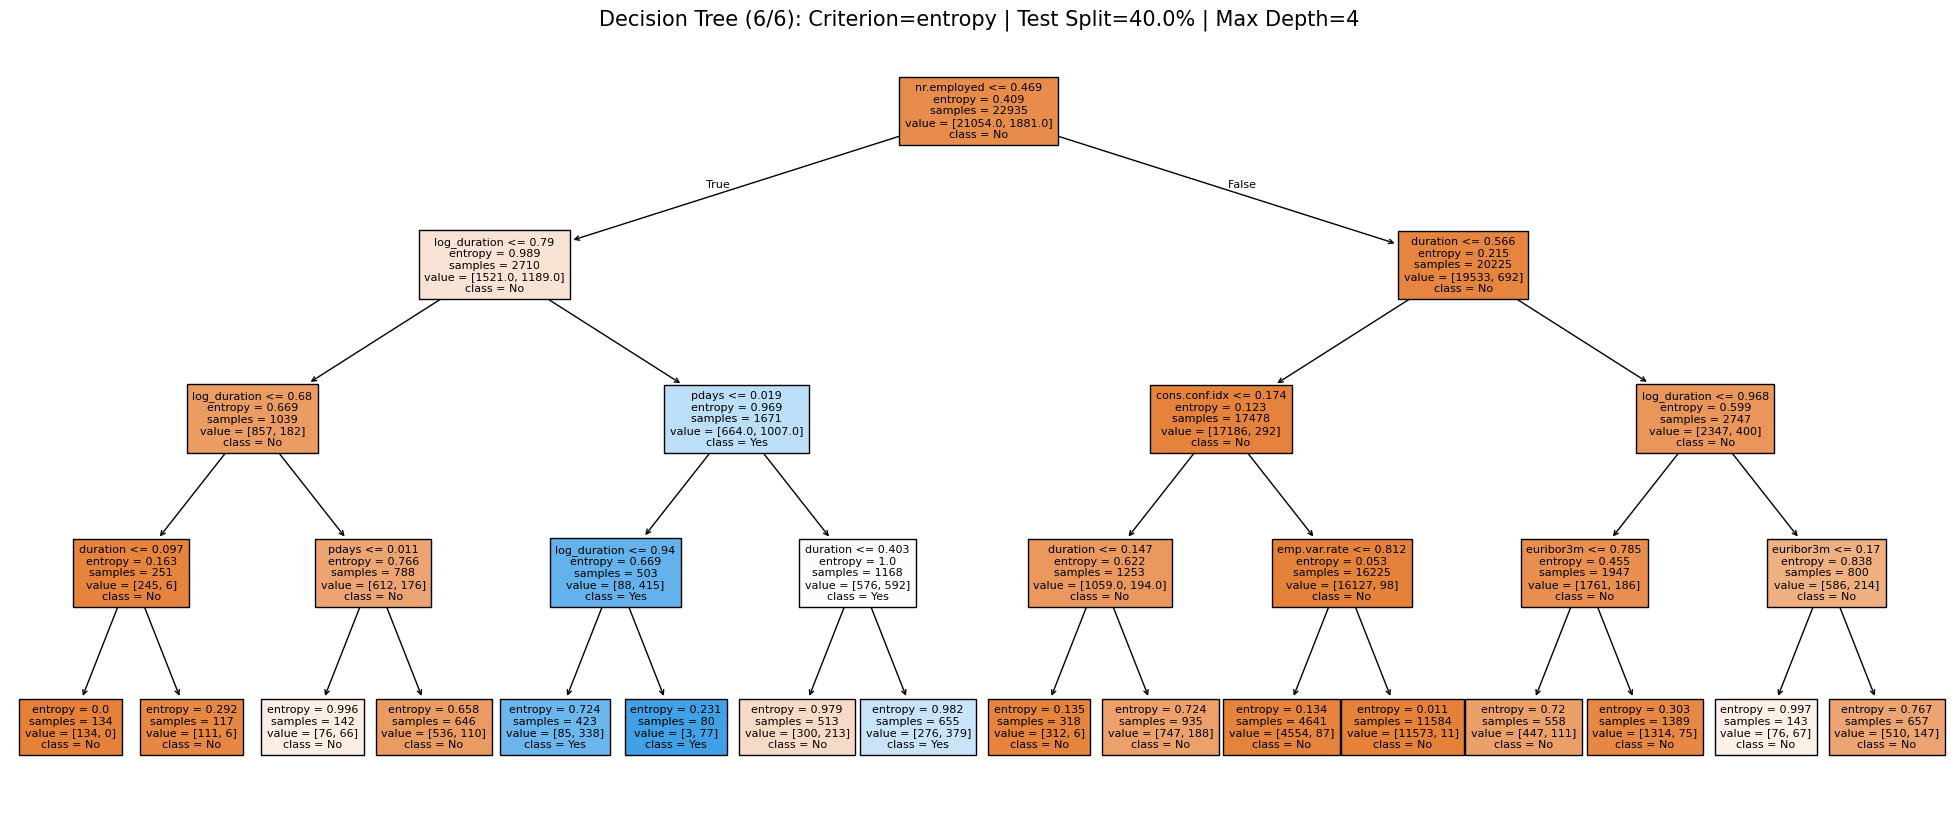

In [78]:
feature_names = X.columns.tolist()
class_names = ['No', 'Yes']

print("Generating 6 Decision Tree visualizations as separate outputs...")

for i, result in enumerate(results_list):
    model = result['Model']
    test_size = result['Test Size']
    criterion = result['Criterion']

    fig, ax = plt.subplots(figsize=(25, 10))

    plot_tree(model,
              feature_names=feature_names,
              class_names=class_names,
              filled=True,
              fontsize=8,
              ax=ax)

    title = f"Decision Tree ({i+1}/6): Criterion={criterion} | Test Split={test_size} | Max Depth={model.max_depth}"
    ax.set_title(title, fontsize=15)


    plt.show()

    plt.close(fig)

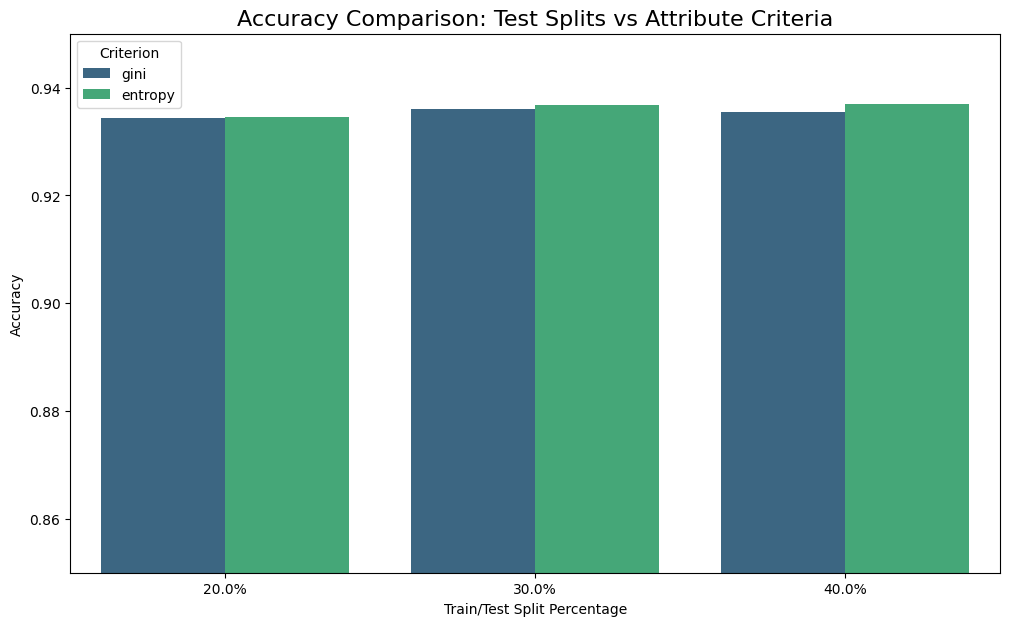

In [79]:
results_df = pd.DataFrame(results_list)

plt.figure(figsize=(12, 7))
sns.barplot(x="Test Size", y="Accuracy", hue="Criterion", data=results_df, palette="viridis")
plt.title("Accuracy Comparison: Test Splits vs Attribute Criteria", fontsize=16)
plt.ylim(0.85, 0.95) # Focusing the view on relevant accuracy range
plt.ylabel("Accuracy")
plt.xlabel("Train/Test Split Percentage")
plt.show()


---

**Clustering**
-

# **[1] Problem**

The main problem is predicting whether a bank client will subscribe to a term deposit. Using customer information and details from previous marketing campaigns, we aim to identify the factors that influence this decision.Solving this problem is important because understanding client behavior helps the bank improve its marketing strategies, reduce unnecessary campaign efforts, and reach the right customers more effectively.

# **[2] Data Mining Task**

The problem is formalized using two data mining tasks:
-

**1- Classification task:**

 Uses the class label “y” to predict whether a client will subscribe to a term deposit, making it a supervised learning approach.


**2- Clustering task:**

Applied as an unsupervised technique to group clients based on similarities in their attributes. This provides insight into natural segments within the dataset and helps explain behavioral patterns beyond the class label.

# **[3] Data**

The dataset contains **41,188 rows** and **21 attributes** that describe bank clients and details related to previous marketing interactions. The attributes include both **categorical** (such as job, marital status, education, and contact type) and **numerical features** (such as age, duration, previous contacts, and employment-related indicators).


The class label (y), indicates whether the client subscribed to a term deposit. Its distribution is **highly imbalanced**, with **36,548 “no”** responses and **4,640 “yes”**, meaning the majority of clients did not subscribe.

# **[4] Data Preprocessing**

During preprocessing, several steps were applied to improve data quality and prepare the dataset for classification and clustering.

These steps are :



**1- Noise Removal (Outlier Handling)**

Why: The duration column had extreme outliers that could distort analysis and mislead models.

How: Outliers were detected and removed using the Interquartile Range (IQR) method (values above Q3 + 1.5×IQR).

Result: The distribution became more stable, reducing noise and improving model accuracy.



**2- Variable Transformation (Log Transformation)**

Why: The duration attribute was highly skewed, which affects algorithms that assume normal-like distributions.

How: A new column log_duration was created using log1p(duration).

Result: The transformation reduced skewness, made the distribution smoother, and prevented large values from dominating.


**3- Discretization (Binning)**

Why: The age column is continuous and had wide variation, making interpretation harder.

How: Age was divided into four age groups (bins).

Result: The attribute became easier to interpret and more suitable for classification models that benefit from categorical inputs.


**4- Normalization (Min–Max Scaling)**

Why: Numeric columns had different scales (e.g., age vs. duration vs. pdays). Without scaling, large-range attributes can dominate distance-based models.

How: Applied Min–Max Scaling to convert all numeric features into the range [0, 1].

Result: All numeric attributes now contribute equally during model training.

**Summary of Results**

After preprocessing, the dataset became cleaner, more balanced, and more suitable for machine learning tasks. Outliers were removed, distributions were smoothed, and numeric attributes were scaled consistently.

# **[5] Data Mining Techniques**

**1- Classification Technique :**

A supervised learning technique used to predict the class label “y” (yes/no) and determine whether a client will subscribe to a term deposit based on their attributes.

**Why :**


* To build a predictive model that learns the relationship between client features and the class label “y”.

* To help the bank identify clients most likely to subscribe.

* Because the dataset contains a class label (y), making it the appropriate technique.

How :

**2- Clustering Technique :**

# **[6] Evaluation and Comparison**

## Classification – Evaluation and Comparison

In this section, a **Decision Tree classifier** was applied using two different attribute selection measures:

- **Gini Index**
- **Information Gain (Entropy)**

Each measure was evaluated under three different data partitioning ratios:

- **80% training / 20% testing**
- **70% training / 30% testing**
- **60% training / 40% testing**

These experiments allow us to compare the performance of both criteria across different data splits.

---

## **1. Summary Tables**

The following two tables summarize the accuracy results for each attribute selection measure, across all partitioning ratios.

### Gini Index – Accuracy Table

|                        | 80% training 20% testing | 70% training 30% testing | 60% training 40% testing |
|------------------------|---------------------------|---------------------------|---------------------------|
| **Accuracy**           | **0.9343** | **0.9361**| **0.9355**|



### Information Gain – Accuracy Table

|                        | 80% training 20% testing | 70% training 30% testing | 60% training 40% testing |
|------------------------|---------------------------|---------------------------|---------------------------|
| **Accuracy**           | **0.9346** | **0.9369**| **0.9370**|

---

## **2. Confusion Matrices**

A confusion matrix was generated for **each combination** of partitioning ratio and attribute selection measure (Gini and Entropy).

These matrices illustrate how well the classifier distinguishes between the two classes ("yes" and "no") and highlight any misclassification patterns.


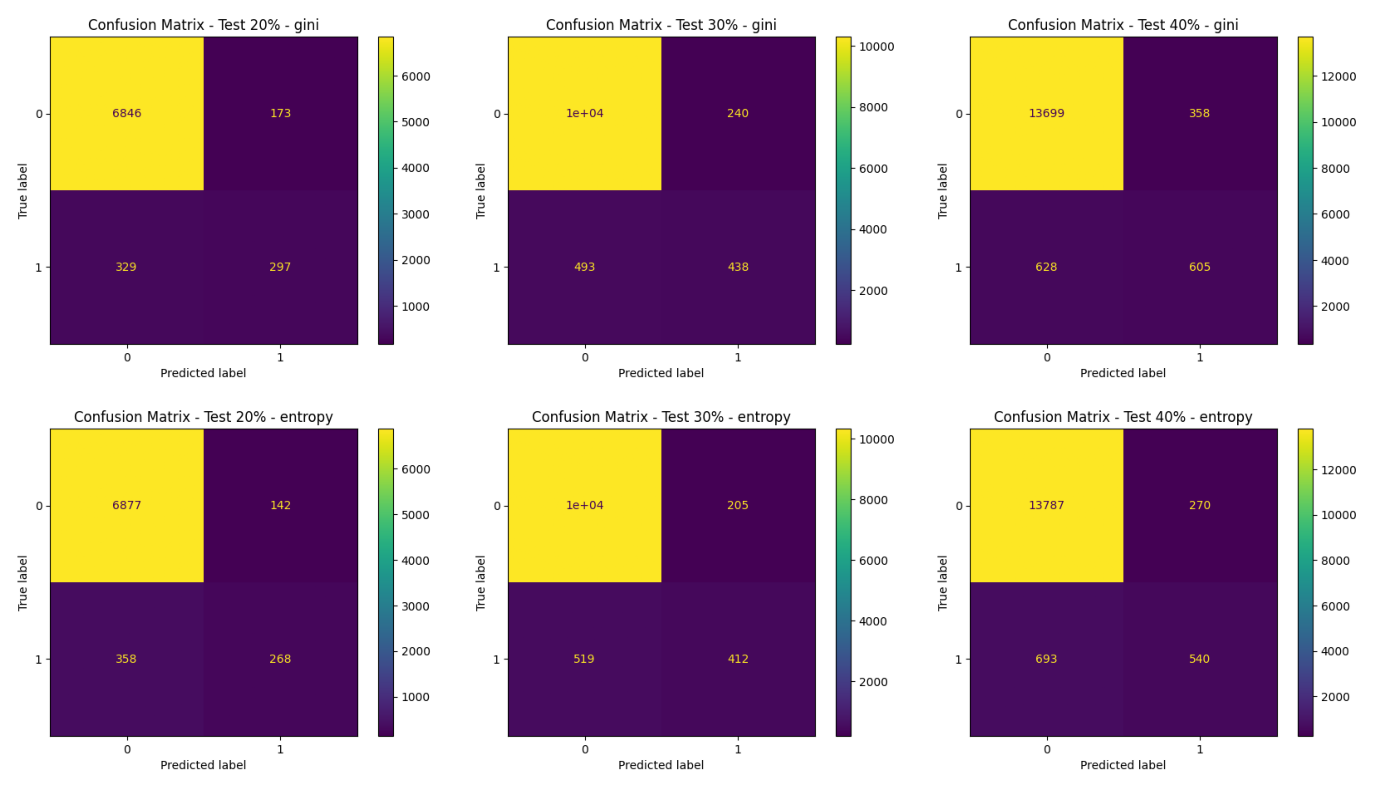

In [31]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


paths = [
    "gini-20.png",
    "gini-30.png",
    "gini-40.png",
    "entropy-20.png",
    "entropy-30.png",
    "entropy-40.png",
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, path in zip(axes.flat, paths):
    img = mpimg.imread(path)
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()


---

## **3. Discussion – Key Insights**

The results reveal several important insights about the performance of the Decision Tree classifier on this dataset.
Across all partitioning ratios (20%, 30%, and 40% testing), the model demonstrates strong and stable performance, with accuracy values consistently high. This indicates that the classifier is not highly sensitive to the choice of training/testing split.

A clear pattern in the confusion matrices shows that the model performs extremely well in predicting the majority class ("no"). Since the dataset is highly imbalanced—where “no” appears far more frequently than “yes”—the classifier naturally learns to predict the majority class with high accuracy.
However, the model is weaker in identifying the minority class ("yes"), resulting in higher false negatives. This misclassification pattern is expected due to the class imbalance present in the Bank Marketing dataset.

When comparing the two attribute selection measures, Entropy consistently performs slightly better than Gini across all partitions. Although the difference is small, it indicates that Entropy may be more effective at recognizing patterns related to the minority class.

---

## **4. Best Algorithm per Partition**

Based on the accuracy values obtained from all experiments:

80/20 partition:
Entropy outperforms Gini (0.9346 vs. 0.9343)

70/30 partition:
Entropy again performs better (0.9369 vs. 0.9361)

60/40 partition:
Entropy achieves the highest accuracy overall (0.9370 vs. 0.9355)

For every individual partitioning ratio, Entropy provides the best performance.

---

## **5. Best Algorithm Overall**

Across all three testing splits (20%, 30%, and 40%),
Entropy consistently outperforms Gini.

The differences are small but stable, showing a clear pattern:

Entropy > Gini in all partitions

Entropy shows slightly better ability to identify the minority class ("yes")

This suggests that Entropy is better suited for this imbalanced dataset.

---

## **6. Final Conclusion**

Entropy is the best-performing attribute selection measure both per-partition and overall, as it consistently achieves higher accuracy across all data splits.

# **[7] Findings and Discussion**

# **[8] References**